Curso: Especialização em Engenharia e Análise de Dados 2026.1.A

Alunos: 
- Pedro Paulo Sant'Anna Belo Ramos
- Stefanny Timoteo Coutinho Brito
- Tanus Henrique Leal Correa
- Weslley Guilherme de Melo

Data: 25/04/2026

Disciplina: Introdução à Análise de Dados

----

# Atividade 02 - Análise de Dados com Pandas

## Importação das Bibliotecas e Análises Iniciais

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('precos_carros_brasil.csv', sep=',', encoding='latin-1')
df.head()


,year_of_reference,month_of_reference,fipe_code,authentication,brand,model,fuel,gear,engine_size,year_model,avg_price_brl
0,2021,January,004001-0,cfzlctzfwrcp,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Gasoline,manual,1,2002,9162
1,2021,January,004001-0,cdqwxwpw3y2p,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Gasoline,manual,1,2001,8832
2,2021,January,004001-0,cb1t3xwwj1xp,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Gasoline,manual,1,2000,8388
3,2021,January,004001-0,cb9gct6j65r0,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Alcohol,manual,1,2000,8453
4,2021,January,004003-7,g15wg0gbz1fx,GM - Chevrolet,Corsa Pick-Up GL/ Champ 1.6 MPFI / EFI,Gasoline,manual,"1,6",2001,12525


## Parte 01

In [3]:
df.describe()

,year_of_reference,year_model,avg_price_brl
count,202297.000000,202297.000000,202297.000000
mean,2021.564694,2011.271527,52756.909153
std,0.571903,6.376234,51628.677716
min,2021.000000,2000.000000,6647.000000
25%,2021.000000,2006.000000,22855.000000
50%,2022.000000,2012.000000,38027.000000
75%,2022.000000,2016.000000,64064.000000
max,2023.000000,2023.000000,979358.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202297 entries, 0 to 202296
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   year_of_reference   202297 non-null  int64 
 1   month_of_reference  202297 non-null  object
 2   fipe_code           202297 non-null  object
 3   authentication      202297 non-null  object
 4   brand               202297 non-null  object
 5   model               202297 non-null  object
 6   fuel                202297 non-null  object
 7   gear                202297 non-null  object
 8   engine_size         202297 non-null  object
 9   year_model          202297 non-null  int64 
 10  avg_price_brl       202297 non-null  int64 
dtypes: int64(3), object(8)
memory usage: 17.0+ MB


### Verificação de Dados Faltantes / Duplicados

#### *Faltantes (Null)*

In [ ]:
# Verificação de valores Null
df.isna().sum()

year_of_reference     0
month_of_reference    0
fipe_code             0
authentication        0
brand                 0
model                 0
fuel                  0
gear                  0
engine_size           0
year_model            0
avg_price_brl         0
dtype: int64

Não foram encontrados dados **Null** no df, não será necessário realizar substituição, ou exclusão, dos dados faltantes

#### *Duplicados*

In [ ]:
# Verificação de valores Duplicados e Remoção das linhas duplicadas
df = df.drop_duplicates()
df

,year_of_reference,month_of_reference,fipe_code,authentication,brand,model,fuel,gear,engine_size,year_model,avg_price_brl
0,2021,January,004001-0,cfzlctzfwrcp,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Gasoline,manual,1,2002,9162
1,2021,January,004001-0,cdqwxwpw3y2p,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Gasoline,manual,1,2001,8832
2,2021,January,004001-0,cb1t3xwwj1xp,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Gasoline,manual,1,2000,8388
3,2021,January,004001-0,cb9gct6j65r0,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Alcohol,manual,1,2000,8453
4,2021,January,004003-7,g15wg0gbz1fx,GM - Chevrolet,Corsa Pick-Up GL/ Champ 1.6 MPFI / EFI,Gasoline,manual,"1,6",2001,12525
...,...,...,...,...,...,...,...,...,...,...,...
202292,2023,January,005538-7,ccv3mvxnsz0dqw,VW - VolksWagen,Saveiro Robust 1.6 Total Flex 16V,Gasoline,manual,"1,6",2023,86038
202293,2023,January,005539-5,chmwfg3l5hbp,VW - VolksWagen,Gol Last Edition 1.0 Flex 12V 5p,Gasoline,manual,1,2023,95997
202294,2023,January,005539-5,cdj27srtcvcdqw,VW - VolksWagen,Gol Last Edition 1.0 Flex 12V 5p,Gasoline,manual,1,2023,87828
202295,2023,January,005540-9,9w64fg6dhqp,VW - VolksWagen,Polo Track 1.0 Flex 12V 5p,Gasoline,manual,1,2023,80845


### Gerando estatísticas Descritivas dos dados com **.describe()**

#### Conversão pra dados do tipo *Category*

In [ ]:
# Transformando catergorias para o padrão do tipo "Category"
df["brand"]= df["brand"].astype("category")
df["fuel"]= df["fuel"].astype("category")
df["gear"]= df["gear"].astype("category")

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 202295 entries, 0 to 202296
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   year_of_reference   202295 non-null  int64   
 1   month_of_reference  202295 non-null  object  
 2   fipe_code           202295 non-null  object  
 3   authentication      202295 non-null  object  
 4   brand               202295 non-null  category
 5   model               202295 non-null  object  
 6   fuel                202295 non-null  category
 7   gear                202295 non-null  category
 8   engine_size         202295 non-null  object  
 9   year_model          202295 non-null  int64   
 10  avg_price_brl       202295 non-null  int64   
dtypes: category(3), int64(3), object(5)
memory usage: 14.5+ MB


#### *Describe()*

In [ ]:
# Dados do tipo NaN encontrados em colunas que não possuem correspondentes na classificação do Describe, como é o caso de valores que não do tipo numerico
df.describe(include = "all")

,year_of_reference,month_of_reference,fipe_code,authentication,brand,model,fuel,gear,engine_size,year_model,avg_price_brl
count,202295.000000,202295,202295,202295,202295,202295,202295,202295,202295,202295.000000,202295.000000
unique,NaN,12,2091,202295,6,2112,3,2,29,NaN,NaN
top,NaN,January,001216-5,cfzlctzfwrcp,Fiat,Palio Week. Adv/Adv TRYON 1.8 mpi Flex,Gasoline,manual,"1,6",NaN,NaN
freq,NaN,24260,425,1,44962,425,168684,161883,47420,NaN,NaN
mean,2021.564695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011.271514,52756.765713
std,0.571904,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.376241,51628.912116
min,2021.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2000.000000,6647.000000
25%,2021.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006.000000,22855.000000
50%,2022.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012.000000,38027.000000
75%,2022.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.000000,64064.000000


In [9]:
df.describe(include="object")

,month_of_reference,fipe_code,authentication,model,engine_size
count,202295,202295,202295,202295,202295
unique,12,2091,202295,2112,29
top,January,001216-5,cfzlctzfwrcp,Palio Week. Adv/Adv TRYON 1.8 mpi Flex,"1,6"
freq,24260,425,1,425,47420


In [ ]:
df.describe(include=["category"])

,brand,fuel,gear
count,202295,202295,202295
unique,6,3,2
top,Fiat,Gasoline,manual
freq,44962,168684,161883


O pandas interpretou os dados do tipo Categorico como **object**, desta estariamos sem dados categoricos, assim definimos "Marca", "Combustivel" e "Câmbio" como dados do tipo categorico.

### Análise Explantória do Dataframe

O dataset possui registros de dados com início em 2021 e término em 2023. É possível analisar seis marcas de carros (Fiat, Ford, GM – Chevrolet, Nissan, Renault e VW – Volkswagen), três tipos de combustível (gasolina, álcool e diesel) e dois tipos de transmissão (manual e automática). Também é possível identificar a maior média de preço de carros, no valor de R$ 979.358,00, e a menor média de R$ 6.647,00, além da média geral de R$ 52.756,90.

## Parte 02

### Gere um gráfico da distribuição da quantidade de carros por marca.

Text(0, 0.5, 'Marca')

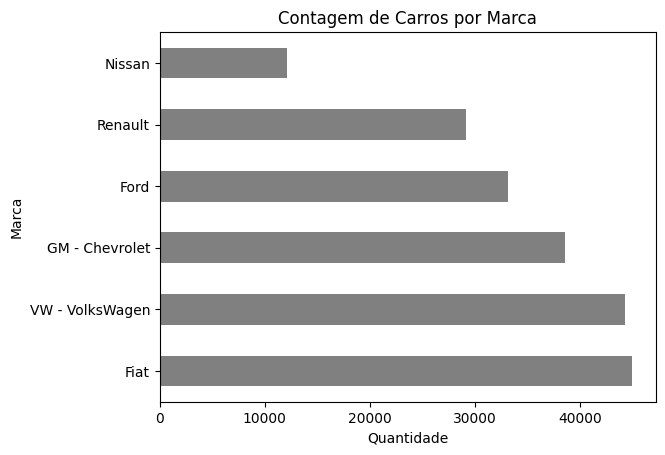

In [27]:
contagem_carros = df["brand"].value_counts()
contagem_carros.plot(kind="barh",color = "gray")
plt.title("Contagem de Carros por Marca")
plt.xlabel("Quantidade")
plt.ylabel("Marca")

### Gere um gráfico da distribuição da quantidade de carros por tipo de engrenagem do carro.

Text(0, 0.5, 'Quantidade')

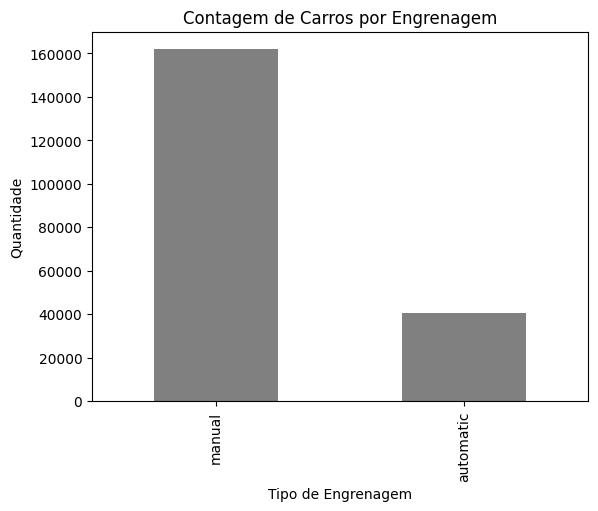

In [28]:
contagem_carros_gear = df["gear"].value_counts()
contagem_carros_gear.plot(kind="bar",color = "gray")
plt.title("Contagem de Carros por Engrenagem")
plt.xlabel("Tipo de Engrenagem")
plt.ylabel("Quantidade")

### Gere um gráfico da evolução da média de preço dos carros ao longo dos meses de 2022 (variável de tempo no eixo X).

<Figure size 5000x500 with 0 Axes>

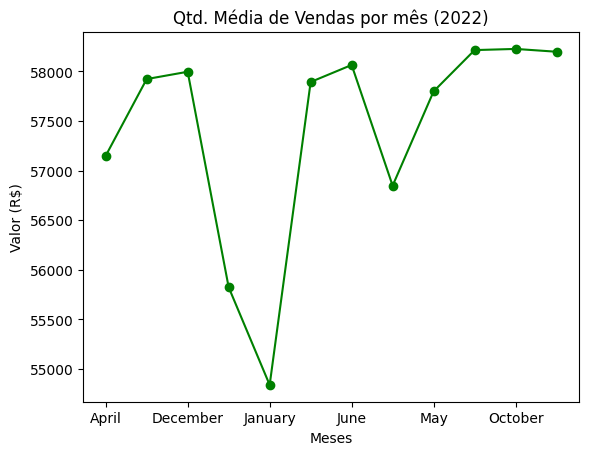

<Figure size 5000x500 with 0 Axes>

In [ ]:
# Gere um gráfico da evolução da média de preço dos carros ao longo dos meses de 2022 (variável de tempo no eixo X).
df_2022 = df[df['year_of_reference'] == 2022]

med_preco_mes = df_2022.groupby('month_of_reference')['avg_price_brl'].mean()
med_preco_mes.plot(marker='o', color='green')
plt.title("Qtd. Média de Vendas por mês (2022)")
plt.xlabel("Meses")
plt.ylabel("Valor (R$)")
plt.figure(figsize=(20,5))

### Gere um gráfico da distribuição da média de preço dos carros por marca e tipo de engrenagem.

/tmp/ipykernel_34283/1163398498.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dist_med_marca_engr = df.groupby(['brand', 'gear'])['avg_price_brl'].mean().unstack()


Text(0, 0.5, 'Preço (R$)')

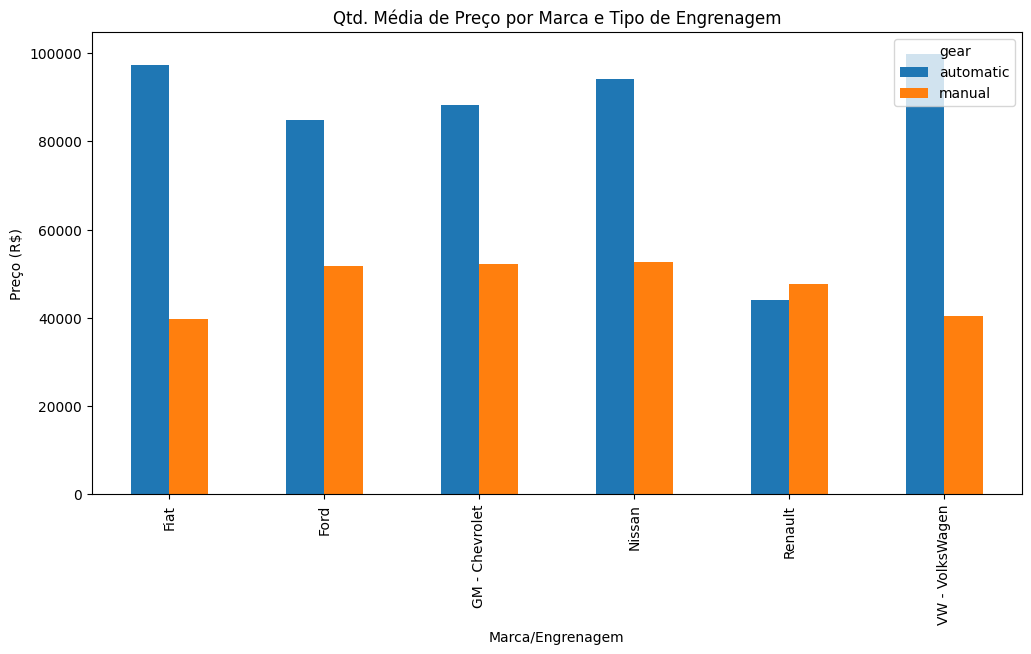

In [51]:
# Gere um gráfico da distribuição da média de preço dos carros por marca e tipo de engrenagem.

dist_med_marca_engr = df.groupby(['brand', 'gear'])['avg_price_brl'].mean().unstack()
dist_med_marca_engr.plot(kind='bar', figsize=(12,6))
plt.title("Qtd. Média de Preço por Marca e Tipo de Engrenagem")
plt.xlabel("Marca/Engrenagem")
plt.ylabel("Preço (R$)")

# foram agrupadas as colunas do df 'marca' e 'tipo de engrenagem' depois calculada a média dos preços para o grupo formado

#### Dê uma breve explicação (máximo de quatro linhas) sobre os resultados gerados no item 4.

Pelo gráfico, dá pra ver que os carros automáticos são mais caros que os manuais em praticamente todas as marcas. Marcas como Volkswagen, Fiat e Nissan têm valores mais altos no automático. Já a Renault é a única que foge um pouco desse padrão, com valores mais próximos entre os dois tipos.

### Gere um gráfico da distribuição da média de preço dos carros por marca e tipo de combustível.

/tmp/ipykernel_34283/1019040496.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  preco_medio_por_marca_combustivel = df.groupby(['brand', 'fuel'])['avg_price_brl'].mean().unstack()


Text(0, 0.5, 'Valor (R$)')

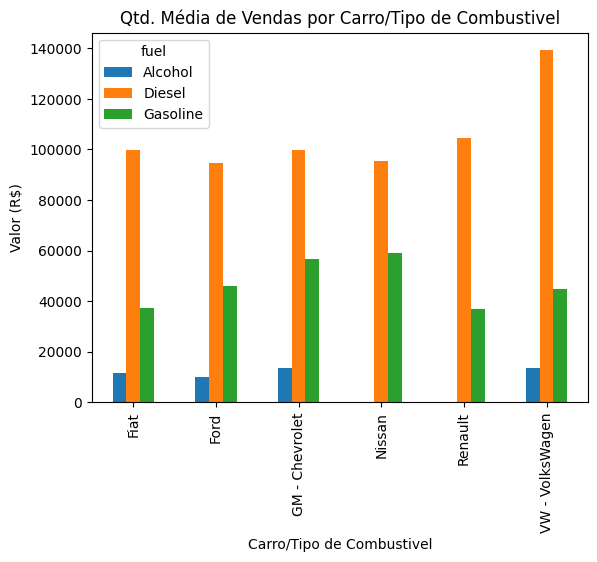

In [50]:
preco_medio_por_marca_combustivel = df.groupby(['brand', 'fuel'])['avg_price_brl'].mean().unstack()
preco_medio_por_marca_combustivel.plot(kind='bar')
plt.title("Qtd. Média de Vendas por Carro/Tipo de Combustivel")
plt.xlabel("Carro/Tipo de Combustivel")
plt.ylabel("Valor (R$)")

#### Dê uma breve explicação (máximo de quatro linhas) sobre os resultados gerados no item 6.

O gráfico mostra que os carros a diesel são os mais caros em todas as marcas analisadas, enquanto os a álcool são os mais baratos. Marcas como Volkswagen e Renault apresentam os maiores preços médios, principalmente no diesel. Já Fiat e Ford tendem a ter valores mais baixos em comparação com as demais. Isso indica que tanto a marca quanto o tipo de combustível influenciam diretamente no preço dos veículos.